# Conteggi e percentuali
In questa sezione verranno presentati alcuni dati generali sulla distribuzione delle lingue per famiglie linguistiche e caratteristiche tipologiche.

In [4]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
import info
import loader
import stats
import plotter

dataset_path = "../dataset/features.csv"
    
try:
    df = loader.load_data(dataset_path)
except FileNotFoundError as e:
    print(f"Error: dataset file ({dataset_path}) not found")
    sys.exit(1)

## Numero di famiglie linguistiche

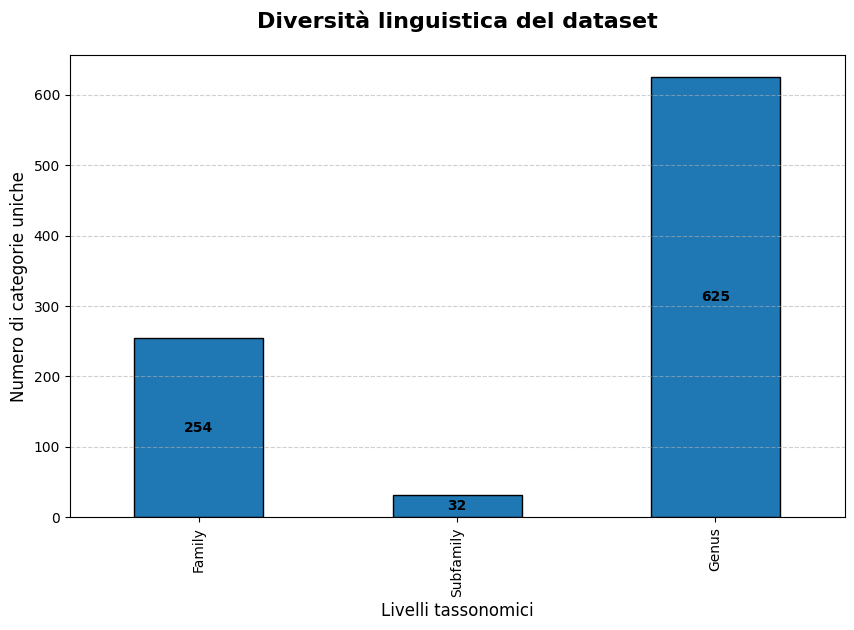

In [5]:
categories_count = df[["Family", "Subfamily", "Genus"]].nunique()
plotter.bar_plot(
    categories_count, 
    title="Diversità linguistica del dataset",
    xlabel="Livelli tassonomici",
    ylabel="Numero di categorie uniche",
    annotate=True
)

## Famiglie linguistiche più numerose

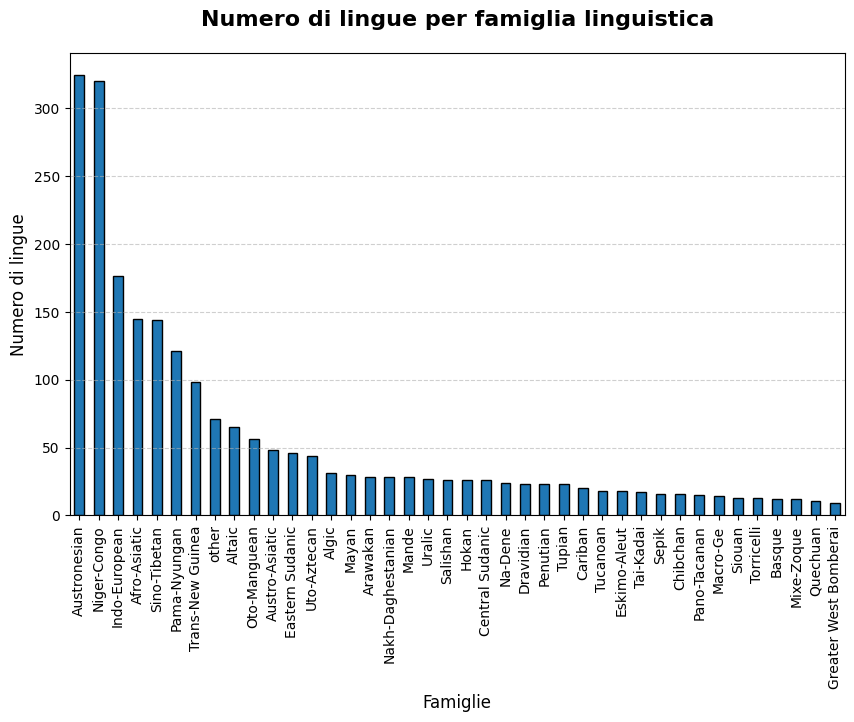

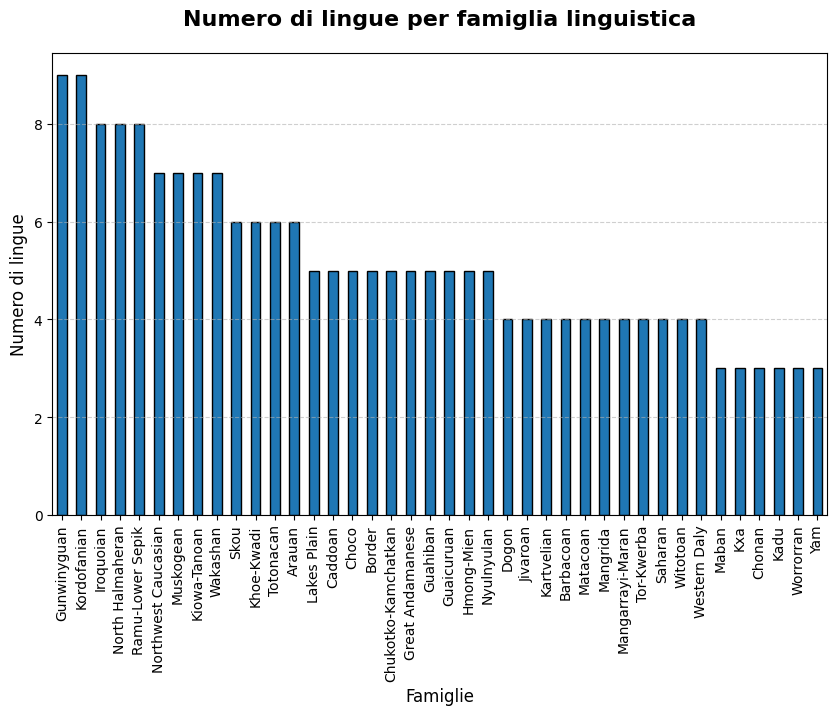

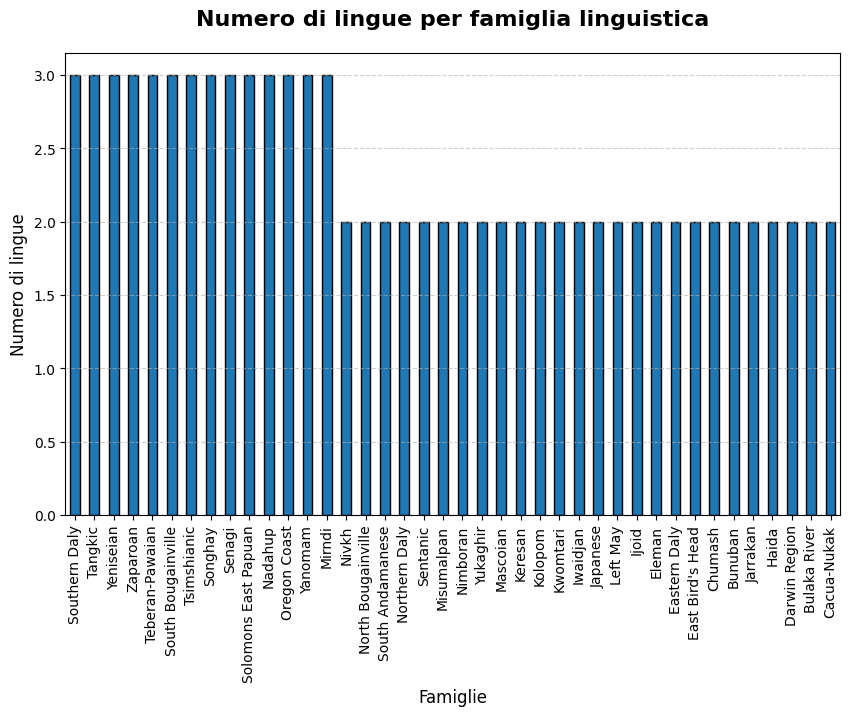

In [6]:

n_top=120
top = df.copy().groupby("Family")["Language_ID"].nunique().sort_values(ascending=False).head(n_top)
others = top.iloc[n_top:]

if not others.empty:
    other_series = pd.Series({"Other": others.sum()})
    languages_by_family = pd.concat([top, other_series])
else:
    languages_by_family = top

languages_by_family_chunks = stats.get_chunks(languages_by_family, 40)

for chunk in languages_by_family_chunks:
    plotter.bar_plot(
        chunk,
        title="Numero di lingue per famiglia linguistica",
        xlabel="Famiglie",
        ylabel="Numero di lingue",
        annotate=False
    )


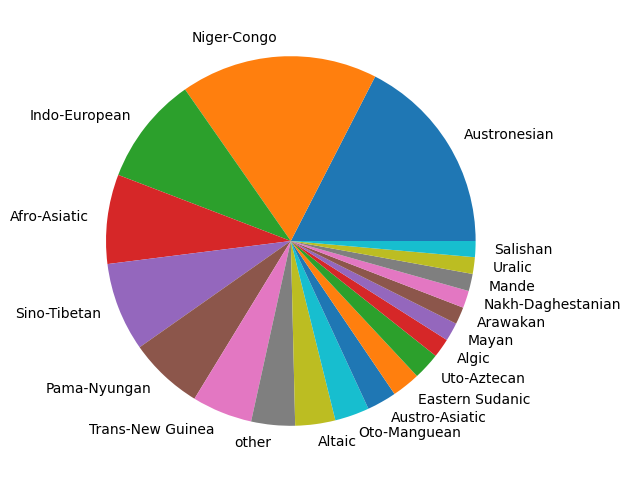

In [9]:
n_top=20
top = df.copy().groupby("Family")["Language_ID"].nunique().sort_values(ascending=False).head(n_top)
others = top.iloc[n_top:]

if not others.empty:
    other_series = pd.Series({"Other": others.sum()})
    languages_by_family = pd.concat([top, other_series])
else:
    languages_by_family = top

plotter.pie_plot(
    languages_by_family
)

## Frequenza per parametro tipologico


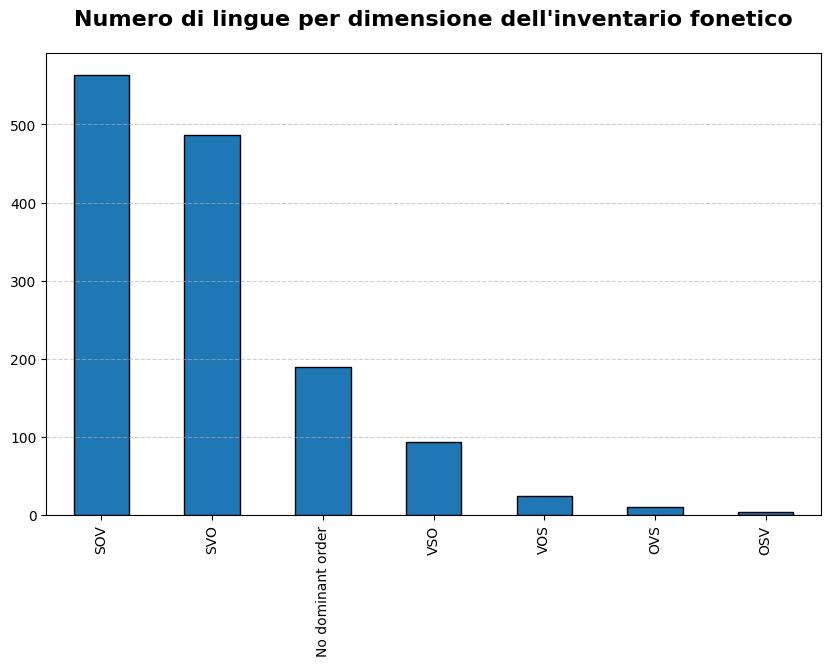

In [25]:
parameter_id = "81A"
qdf = df.copy()
qdf = qdf[qdf["Parameter_ID"] == parameter_id]
qdf = qdf.groupby("Code_Name")["Language_ID"].nunique().sort_values(ascending=False)

plotter.bar_plot(
    qdf,
    title="Numero di lingue per dimensione dell'inventario fonetico",
)